# Evaluación de Modelos Generativos: Continuous Ranked Probability Score (CRPS)

### 1. Marco Teórico y Motivación
En el contexto de la **Propuesta de Tesis de Magíster en IA**, la evaluación de modelos no puede limitarse a métricas deterministas como el MAE o RMSE. Dado que el objetivo es capturar la naturaleza estocástica de series multivariadas (como el USD/CLP o el Cobre), requerimos una métrica que evalúe la **calidad de la distribución completa**.

El **CRPS** es la métrica de oro para modelos de **Transformers y Difusión**, ya que mide simultáneamente:
1. **Calibración:** Qué tan cerca está la observación real de la masa de probabilidad generada.
2. **Nitidez (Sharpness):** Qué tan concentradas están las trayectorias generadas (evitando incertidumbre excesiva).

### 2. Formulación Matemática
El CRPS se define como la integral del cuadrado de la diferencia entre la Función de Distribución Acumulada (CDF) del pronóstico, $F$, y la función escalón de la observación real $y$:

$$CRPS(F, y) = \int_{-\infty}^{\infty} [F(x) - \mathbb{1}_{x \ge y}]^2 dx$$

Para nuestra implementación basada en **muestreo de Monte Carlo** (trayectorias generadas por el modelo de difusión), utilizamos la forma de representación de Gneiting y Raftery:

$$CRPS(F, y) = E_F|X - y| - \frac{1}{2} E_F|X - X'|$$



### 3. Descomposición del Cálculo
En el script a continuación, se aplican dos términos críticos identificados en nuestra arquitectura:

* **Término 1 (`term_1`):** Error absoluto medio entre las muestras del modelo y la realidad ($E|X - y|$).
* **Término 2 (`term_2`):** La diferencia media interna entre todas las trayectorias generadas ($\frac{1}{2}E|X - X'|$). Este término actúa como un regularizador que penaliza si el modelo de difusión genera escenarios demasiado dispersos o incoherentes.

---

In [ ]:
import numpy as np

def calculate_crps(observations, forecasts):
    """
    Calcula el CRPS para una observación frente a múltiples trayectorias (forecasts).
    observations: array de valores reales (N,)
    forecasts: array de trayectorias generadas (N, num_muestras)
    """
    # Término 1: Error absoluto medio entre predicción y observación
    term_1 = np.mean(np.abs(forecasts - observations[:, None]), axis=1)

    # Término 2: Diferencia media interna entre todas las trayectorias (castiga la dispersión excesiva)
    # Usamos una optimización vectorial para evitar bucles anidados
    n_samples = forecasts.shape[1]
    forecasts_sorted = np.sort(forecasts, axis=1)
    diff_internal = np.zeros(forecasts.shape[0])

    for i in range(n_samples):
        diff_internal += (i * (n_samples - i)) * (forecasts_sorted[:, i] - forecasts_sorted[:, i-1])

    term_2 = (1.0 / (n_samples**2)) * diff_internal

    return term_1 - term_2

# Ejemplo de uso:
obs = np.array([10.5]) # Valor real del dólar (ejemplo)
# 1000 trayectorias generadas por tu modelo de difusión
pred_muestras = np.random.normal(loc=10.2, scale=0.8, size=(1, 1000))

score = calculate_crps(obs, pred_muestras)
print(f"CRPS Score: {score[0]:.4f}")

CRPS Score: 0.2422


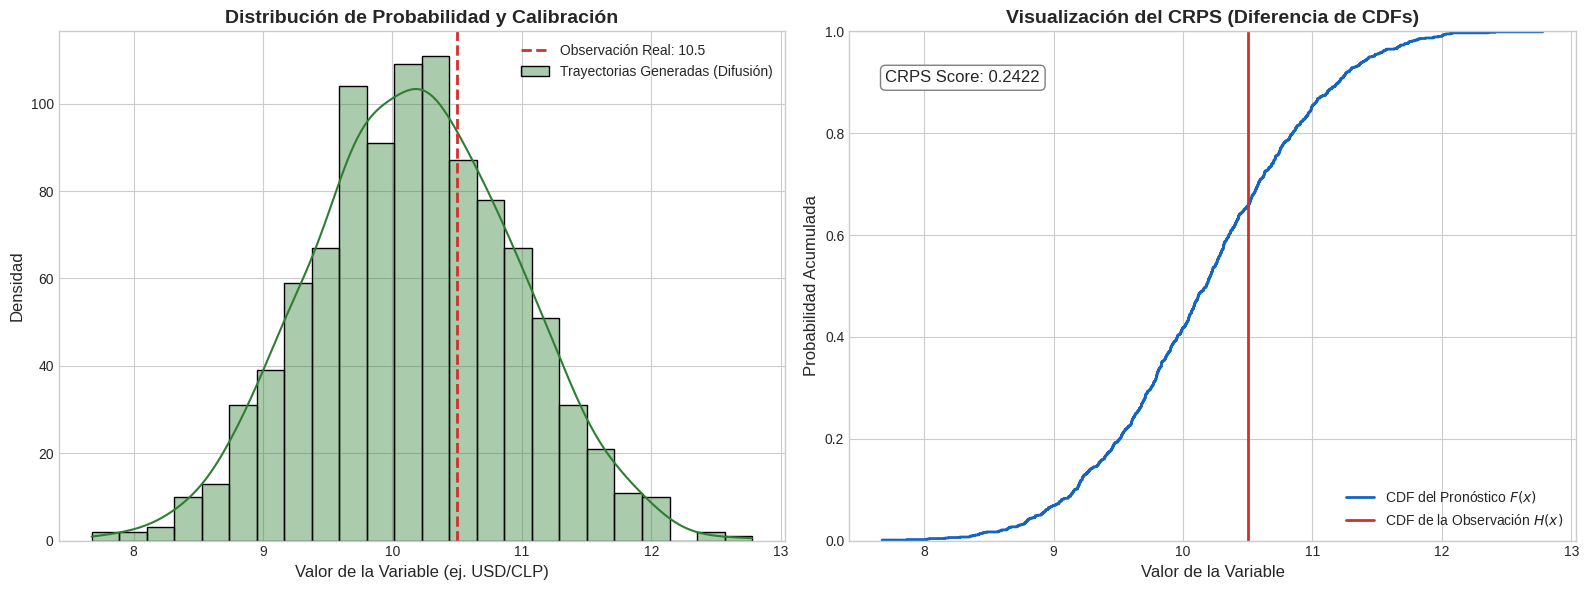

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estética profesional
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PANEL 1: Función de Densidad (PDF) e Incertidumbre ---
sns.histplot(pred_muestras.flatten(), kde=True, ax=ax1, color='#2e7d32', alpha=0.4, label='Trayectorias Generadas (Difusión)')
ax1.axvline(obs[0], color='#d32f2f', linestyle='--', linewidth=2, label=f'Observación Real: {obs[0]}')

ax1.set_title('Distribución de Probabilidad y Calibración', fontsize=14, fontweight='bold')
ax1.set_xlabel('Valor de la Variable (ej. USD/CLP)', fontsize=12)
ax1.set_ylabel('Densidad', fontsize=12)
ax1.legend()

# --- PANEL 2: Función de Distribución Acumulada (CDF) ---
# El CRPS es el área al cuadrado entre estas dos curvas
sns.ecdfplot(pred_muestras.flatten(), ax=ax2, color='#1565c0', linewidth=2, label='CDF del Pronóstico $F(x)$')
ax2.step(sorted([obs[0], obs[0]]), [0, 1], color='#d32f2f', linewidth=2, label='CDF de la Observación $H(x)$')

# Rellenar el área que representa el CRPS (esquemático)
ax2.set_title('Visualización del CRPS (Diferencia de CDFs)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Valor de la Variable', fontsize=12)
ax2.set_ylabel('Probabilidad Acumulada', fontsize=12)
ax2.annotate(f'CRPS Score: {score[0]:.4f}', xy=(0.05, 0.9), xycoords='axes fraction',
             fontsize=12, bbox=dict(boxstyle="round", fc="white", ec="gray"))
ax2.legend()

plt.tight_layout()
plt.show()

# GARCH

In [ ]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 21.5 MB/s eta 0:00:00


Iteration:      1,   Func. Count:      6,   Neg. LLF: 8571473166.555978
Iteration:      2,   Func. Count:     14,   Neg. LLF: 117868.56399049723
Iteration:      3,   Func. Count:     24,   Neg. LLF: 1405.5971605484442
Iteration:      4,   Func. Count:     30,   Neg. LLF: 1417.0542984258855
Iteration:      5,   Func. Count:     36,   Neg. LLF: 1412.4274221851501
Iteration:      6,   Func. Count:     42,   Neg. LLF: 1410.3285336704275
Iteration:      7,   Func. Count:     48,   Neg. LLF: 1411.1006146225204
Iteration:      8,   Func. Count:     54,   Neg. LLF: 1411.9883726331973
Iteration:      9,   Func. Count:     60,   Neg. LLF: 1412.3632509612285
Iteration:     10,   Func. Count:     66,   Neg. LLF: 1425.0867073987338
Iteration:     11,   Func. Count:     72,   Neg. LLF: 1433.3466835627369
Iteration:     12,   Func. Count:     78,   Neg. LLF: 3435.546932166074
Iteration:     13,   Func. Count:     87,   Neg. LLF: 13689324687.319016
Iteration:     14,   Func. Count:     96,   Neg. LLF:

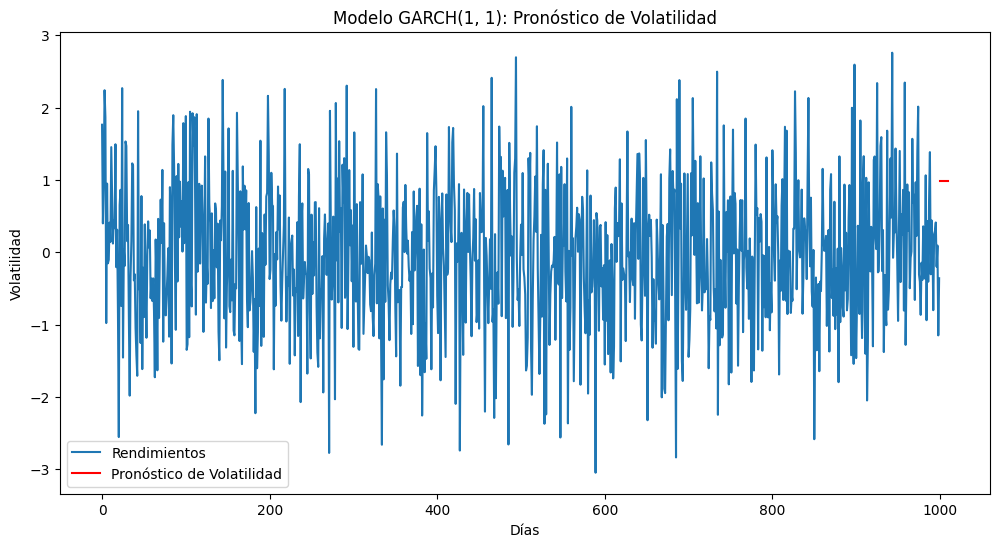

In [ ]:
import numpy as np
import pandas as pd
import arch
from arch import arch_model
import matplotlib.pyplot as plt

# Crear una serie de tiempo sintética (reemplaza esto con tus datos)
np.random.seed(0)
returns = np.random.randn(1000)

# Crear un DataFrame de pandas con la serie de tiempo
df = pd.DataFrame({'Returns': returns})

# Especificar y ajustar un modelo GARCH(1, 1)
model = arch_model(df['Returns'], vol='Garch', p=1, q=1)
results = model.fit()

# Resumen de la estimación del modelo
print(results.summary())

# Generar pronósticos de volatilidad
horizon = 10
forecasts = results.forecast(start=0, horizon=horizon)
volatility_forecast = np.sqrt(forecasts.variance.values[-1, :])

# Visualizar los pronósticos de volatilidad
plt.figure(figsize=(12, 6))
plt.plot(df['Returns'], label='Rendimientos')
plt.plot(np.arange(len(df), len(df) + horizon), volatility_forecast, label='Pronóstico de Volatilidad', color='red')
plt.title('Modelo GARCH(1, 1): Pronóstico de Volatilidad')
plt.xlabel('Días')
plt.ylabel('Volatilidad')
plt.legend()
plt.show()